### Is Cov comparaible across different chunk sizes!

Truth 1 : The variance of each TN will decrease as chunk size increases

Truth 2 : The *difference* between TN counts will increase as chunk size increases 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# What happens to covariance under Truth 1 

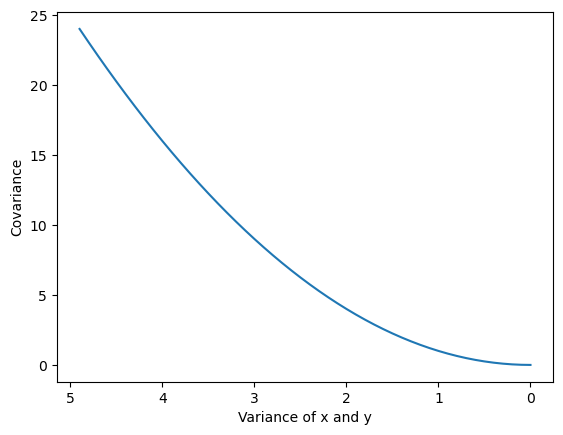

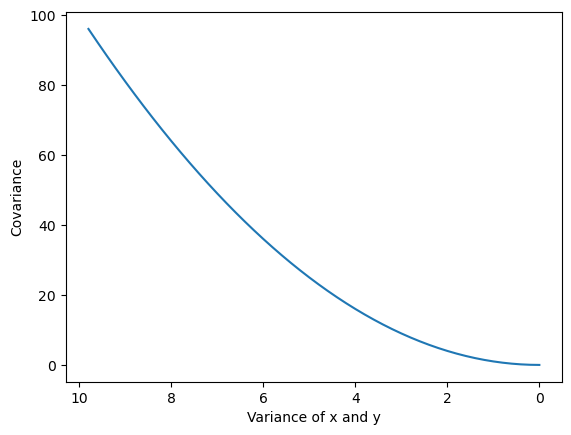

In [18]:
def Generate_cov(std_x, std_y, rho):
    cov_matrix = np.array([[std_x**2, rho*std_x*std_y],
                       [rho*std_x*std_y, std_y**2]])
    return cov_matrix

def Plot_cov_var(List_variances, List_cov):
    plt.plot(List_variances, List_cov)
    plt.xlabel("Variance of x and y")
    plt.ylabel("Covariance") 
    plt.gca().invert_xaxis()
    plt.show()


# How does the slope change when the rate of std is different 

Correlation = 1

# Two sampling rates for std
# Increasing the std, simply results in higher correlation values 
# because the correlation is not being weakened by random variation 

XY_rate_1 = np.arange(0, 5, 0.1)
XY_rate_2 = np.arange(0, 10, 0.2)

# Make into array 
Array = np.array([XY_rate_1, XY_rate_2], dtype=object)


for row in Array:
    Cov_values = []
    for std in row: 
        Cov = Generate_cov(std, std, Correlation)[0][1]
        Cov_values.append(Cov)
    Plot_cov_var(row, Cov_values)



## My beleifs

#### Very low chunk sizes (100 to 500)

The counts of both TN will be too low to have reliable correlation - regarldess of the number of samples

Thus, I would expect Covariance values to vary greatly after each and every sample 

### medium chunk sizes (500 to 5000) 

The count of TN will stabilise (dependant on the TN frequency) 

Thus, correlation will begin to stabilise between consequetive sampling

### large chunk sizes (> 5000)

The count of (most) TN will stabilise completely - the true correlation will be revealed 

However, the variance of the TN between chunk sizes will be very low

Thus, the covariance will asymptote to zero


### The effect of increasing sample size 

I think it will increase the ability use smaller chunk sizes to get the Covariance - but it will asmpytote - at a certain chunk size, it doesn't matter how many chunks you take, the TN counts are too unreliable

### The effect of multiple sampling

Repeatedly taking new samples at a given chunk size will result in a range of cov values, in which the mean will converge on the *true* cov. The width of the range will be dependant on the number of samples taken.

### The effect of the saturated model 

Saturated model = largest number of independent chunks possible.

By saturated model I mean n_chunk_samples = len_genome. (meaning, if the genome was 1000 bp, and our chunk sizes were 10. Thne the satured model would be 90 - ie, n_chunk_samples = 90 (any more would result in either 100% overlapping chunks, or chunks which are not of the minimum length).

What the saturated model *actually* represents I am not sure... Perhaps it reflects the *true* covariance?


### The effect of overlapping TN (ATCGA --> ATCG and TCGA) 

All four variants of leading / training overlapping TN will have much higher correlations 
* eg : ATCG should have a correlation of 0.25 with each of TCGA, TCGG, TCGC, TCGT due to sequence dependency 
* Compared to ATCG with TAGC - which should have a correlation of X by random chance


Thus, at lower chunk sizes, overlapping tetramers will have artifically inflated correlations values. This will be reflected by much higher covariance values - and it will be stable upon repeated sampling - because they violate the assumption of independency. 

However, we the covariance / correlation estimates of leading / training overlapping TN is just as meaningless as other TN combinations at lower chunk sizes. Because we simply are not drawing a large enough sampling size to identify if there is a a stronger correlation with a one of the four possible overlapping TN in enriched compared to the others. 


<span style="color: red">As a result I expect the curves of overlapping TN to be different compared to non-overlapping TN.</span>  


Firstly, I would expect almost all to have a positive correlation across all chunk sizes (due to sequnece dependency). If a negative correlation is observed (it is possible that ATCG and TCGA do not have a positive correlation) it would be *very* interesting and is (maybe) more significant that two completely non-overlapping TN having a negative correlation. 

Secondly, I would expect that correlation at very low chunk sizes to fluctate around 0.25, rather than 0 compard to completely non-overlapping TN. 

Thirdly, I would expect that correlation for *independant* (no correlation) sequnece dependant (tri overlapping) TN to simply fluctuate around 0.25. This will be reflected in *covariance* as Higher covariance at lower chunk sizes, and then asyptoting to a smaller value as variance decreases - I dont think it will asympotote to zero like non-overlapping TN. 

Fourthly, I would expect that *co-variance* for overlapping TN in which one of the four combinations is *truely enriched* will be nonsensical at lower chunk sizes - but on average HIGHER than non-overlapping. and as chunk size increases, the shape of the curve should be the same as non-overlapping TN.  


## Other thoughts 

For overlapping kmers, will the *covariance* asmptote to zero at a different rate dpeendant on the number of overlapping bases


is the higher *covariance* between leading/training overlapping kmers going to misinform the mahalanobis distance estimates? 
